In [ ]:
!pip install huggingface_hub

In [ ]:
from huggingface_hub import hf_hub_download
import os

repo_id = "lnxdre4d/push_t"
filename = "pusht_goal_features.tar"
local_dir = "/content"

print(f"Downloading {filename} from Hugging Face...")

tar_path = hf_hub_download(
    repo_id=repo_id,
    filename=filename,
    repo_type="dataset",
    local_dir=local_dir
)

print(f"Downloaded to: {tar_path}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pusht_goal_features.tar:   0%|          | 0.00/6.32G [00:00<?, ?B/s]

Downloaded to: /content/pusht_goal_features.tar


In [ ]:
import tarfile

tar_path="/content/pusht_goal_features.tar"
extract_path = "/content/push_t.zarr"

if not os.path.exists(extract_path):
    os.makedirs(extract_path)

print(f"Extracting {tar_path} to {extract_path}...")

with tarfile.open(tar_path, 'r') as tar:
    tar.extractall(path=extract_path)

print(f"Extraction complete! Your Zarr store is ready at: {extract_path}/pusht_goal_features.zarr")

Extracting /content/pusht_goal_features.tar to /content/push_t.zarr...


/tmp/ipykernel_1288/688382894.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Extraction complete! Your Zarr store is ready at: /content/push_t.zarr/pusht_goal_features.zarr


In [ ]:
!pip install gdown
!gdown 1XkZ4nF51Zf2aKyS9Z_OM25-vMYAy6psu

Downloading...
From (original): https://drive.google.com/uc?id=1XkZ4nF51Zf2aKyS9Z_OM25-vMYAy6psu
From (redirected): https://drive.google.com/uc?id=1XkZ4nF51Zf2aKyS9Z_OM25-vMYAy6psu&confirm=t&uuid=5899d051-26af-46b4-8249-cd3cfbfbb085
To: /content/duplo_pusht_epoch_100.pt
100% 911M/911M [00:33<00:00, 27.6MB/s]


In [ ]:
!python --version
!pip install torch torchvision torchaudio \
  --index-url https://download.pytorch.org/whl/cu128
!pip3 install diffusers \
scikit-image scikit-video "zarr>=3" numcodecs \
pygame pymunk==6.2.1 gym==0.26.2 shapely

Python 3.12.13
Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 65.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 65.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 139.4 MB/s eta 0:00:00
  Created wheel for pymunk: filename=pymunk-6.2.1-cp312-cp312-linux_x86_64.whl size=806458 sha256=7f21b3168d063ec44c7a2894cde61498aaf5f260c9d0fe14912108effe25fa79
  Stored in directory: /root/.cache/pip/wheels/1f/e6/2f/d319e521bf941a17042f73b0e25395e125f8eeca

In [ ]:
!pip install transformers

In [ ]:
# diffusion policy import
from typing import Tuple, Sequence, Dict, Union, Optional, Callable
import numpy as np
import math
import torch
import torch.nn as nn
import torchvision
import collections
import zarr
from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
from diffusers.training_utils import EMAModel
from diffusers.optimization import get_scheduler
from tqdm.auto import tqdm

# env import
import gym
from gym import spaces
import pygame
import pymunk
import pymunk.pygame_util
from pymunk.space_debug_draw_options import SpaceDebugColor
from pymunk.vec2d import Vec2d
import shapely.geometry as sg
import cv2
import skimage.transform as st
from skvideo.io import vwrite
from IPython.display import Video
import gdown
import os

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [ ]:
positive_y_is_up: bool = False
"""Make increasing values of y point upwards.

When True::

    y
    ^
    |      . (3, 3)
    |
    |   . (2, 2)
    |
    +------ > x

When False::

    +------ > x
    |
    |   . (2, 2)
    |
    |      . (3, 3)
    v
    y

"""

def to_pygame(p: Tuple[float, float], surface: pygame.Surface) -> Tuple[int, int]:
    """Convenience method to convert pymunk coordinates to pygame surface
    local coordinates.

    Note that in case positive_y_is_up is False, this function wont actually do
    anything except converting the point to integers.
    """
    if positive_y_is_up:
        return round(p[0]), surface.get_height() - round(p[1])
    else:
        return round(p[0]), round(p[1])


def light_color(color: SpaceDebugColor):
    color = np.minimum(1.2 * np.float32([color.r, color.g, color.b, color.a]), np.float32([255]))
    color = SpaceDebugColor(r=color[0], g=color[1], b=color[2], a=color[3])
    return color

class DrawOptions(pymunk.SpaceDebugDrawOptions):
    def __init__(self, surface: pygame.Surface) -> None:
        """Draw a pymunk.Space on a pygame.Surface object.

        Typical usage::

        >>> import pymunk
        >>> surface = pygame.Surface((10,10))
        >>> space = pymunk.Space()
        >>> options = pymunk.pygame_util.DrawOptions(surface)
        >>> space.debug_draw(options)

        You can control the color of a shape by setting shape.color to the color
        you want it drawn in::

        >>> c = pymunk.Circle(None, 10)
        >>> c.color = pygame.Color("pink")

        See pygame_util.demo.py for a full example

        Since pygame uses a coordiante system where y points down (in contrast
        to many other cases), you either have to make the physics simulation
        with Pymunk also behave in that way, or flip everything when you draw.

        The easiest is probably to just make the simulation behave the same
        way as Pygame does. In that way all coordinates used are in the same
        orientation and easy to reason about::

        >>> space = pymunk.Space()
        >>> space.gravity = (0, -1000)
        >>> body = pymunk.Body()
        >>> body.position = (0, 0) # will be positioned in the top left corner
        >>> space.debug_draw(options)

        To flip the drawing its possible to set the module property
        :py:data:`positive_y_is_up` to True. Then the pygame drawing will flip
        the simulation upside down before drawing::

        >>> positive_y_is_up = True
        >>> body = pymunk.Body()
        >>> body.position = (0, 0)
        >>> # Body will be position in bottom left corner

        :Parameters:
                surface : pygame.Surface
                    Surface that the objects will be drawn on
        """
        self.surface = surface
        super(DrawOptions, self).__init__()

    def draw_circle(
        self,
        pos: Vec2d,
        angle: float,
        radius: float,
        outline_color: SpaceDebugColor,
        fill_color: SpaceDebugColor,
    ) -> None:
        p = to_pygame(pos, self.surface)

        pygame.draw.circle(self.surface, fill_color.as_int(), p, round(radius), 0)
        pygame.draw.circle(self.surface, light_color(fill_color).as_int(), p, round(radius-4), 0)

        circle_edge = pos + Vec2d(radius, 0).rotated(angle)
        p2 = to_pygame(circle_edge, self.surface)
        line_r = 2 if radius > 20 else 1
        # pygame.draw.lines(self.surface, outline_color.as_int(), False, [p, p2], line_r)

    def draw_segment(self, a: Vec2d, b: Vec2d, color: SpaceDebugColor) -> None:
        p1 = to_pygame(a, self.surface)
        p2 = to_pygame(b, self.surface)

        pygame.draw.aalines(self.surface, color.as_int(), False, [p1, p2])

    def draw_fat_segment(
        self,
        a: Tuple[float, float],
        b: Tuple[float, float],
        radius: float,
        outline_color: SpaceDebugColor,
        fill_color: SpaceDebugColor,
    ) -> None:
        p1 = to_pygame(a, self.surface)
        p2 = to_pygame(b, self.surface)

        r = round(max(1, radius * 2))
        pygame.draw.lines(self.surface, fill_color.as_int(), False, [p1, p2], r)
        if r > 2:
            orthog = [abs(p2[1] - p1[1]), abs(p2[0] - p1[0])]
            if orthog[0] == 0 and orthog[1] == 0:
                return
            scale = radius / (orthog[0] * orthog[0] + orthog[1] * orthog[1]) ** 0.5
            orthog[0] = round(orthog[0] * scale)
            orthog[1] = round(orthog[1] * scale)
            points = [
                (p1[0] - orthog[0], p1[1] - orthog[1]),
                (p1[0] + orthog[0], p1[1] + orthog[1]),
                (p2[0] + orthog[0], p2[1] + orthog[1]),
                (p2[0] - orthog[0], p2[1] - orthog[1]),
            ]
            pygame.draw.polygon(self.surface, fill_color.as_int(), points)
            pygame.draw.circle(
                self.surface,
                fill_color.as_int(),
                (round(p1[0]), round(p1[1])),
                round(radius),
            )
            pygame.draw.circle(
                self.surface,
                fill_color.as_int(),
                (round(p2[0]), round(p2[1])),
                round(radius),
            )

    def draw_polygon(
        self,
        verts: Sequence[Tuple[float, float]],
        radius: float,
        outline_color: SpaceDebugColor,
        fill_color: SpaceDebugColor,
    ) -> None:
        ps = [to_pygame(v, self.surface) for v in verts]
        ps += [ps[0]]

        radius = 2
        pygame.draw.polygon(self.surface, light_color(fill_color).as_int(), ps)

        if radius > 0:
            for i in range(len(verts)):
                a = verts[i]
                b = verts[(i + 1) % len(verts)]
                self.draw_fat_segment(a, b, radius, fill_color, fill_color)

    def draw_dot(
        self, size: float, pos: Tuple[float, float], color: SpaceDebugColor
    ) -> None:
        p = to_pygame(pos, self.surface)
        pygame.draw.circle(self.surface, color.as_int(), p, round(size), 0)


def pymunk_to_shapely(body, shapes):
    geoms = list()
    for shape in shapes:
        if isinstance(shape, pymunk.shapes.Poly):
            verts = [body.local_to_world(v) for v in shape.get_vertices()]
            verts += [verts[0]]
            geoms.append(sg.Polygon(verts))
        else:
            raise RuntimeError(f'Unsupported shape type {type(shape)}')
    geom = sg.MultiPolygon(geoms)
    return geom

# env
class PushTEnv(gym.Env):
    metadata = {"render.modes": ["human", "rgb_array"], "video.frames_per_second": 10}
    reward_range = (0., 1.)

    def __init__(self,
            legacy=False,
            block_cog=None, damping=None,
            render_action=True,
            render_size=96,
            reset_to_state=None
        ):
        self._seed = None
        self.seed()
        self.window_size = ws = 512  # The size of the PyGame window
        self.render_size = render_size
        self.sim_hz = 100
        # Local controller params.
        self.k_p, self.k_v = 100, 20    # PD control.z
        self.control_hz = self.metadata['video.frames_per_second']
        # legcay set_state for data compatiblity
        self.legacy = legacy

        # agent_pos, block_pos, block_angle
        self.observation_space = spaces.Box(
            low=np.array([0,0,0,0,0], dtype=np.float64),
            high=np.array([ws,ws,ws,ws,np.pi*2], dtype=np.float64),
            shape=(5,),
            dtype=np.float64
        )

        # positional goal for agent
        self.action_space = spaces.Box(
            low=np.array([0,0], dtype=np.float64),
            high=np.array([ws,ws], dtype=np.float64),
            shape=(2,),
            dtype=np.float64
        )

        self.block_cog = block_cog
        self.damping = damping
        self.render_action = render_action

        """
        If human-rendering is used, `self.window` will be a reference
        to the window that we draw to. `self.clock` will be a clock that is used
        to ensure that the environment is rendered at the correct framerate in
        human-mode. They will remain `None` until human-mode is used for the
        first time.
        """
        self.window = None
        self.clock = None
        self.screen = None

        self.space = None
        self.teleop = None
        self.render_buffer = None
        self.latest_action = None
        self.reset_to_state = reset_to_state

    def reset(self):
        seed = self._seed
        self._setup()
        if self.block_cog is not None:
            self.block.center_of_gravity = self.block_cog
        if self.damping is not None:
            self.space.damping = self.damping

        # use legacy RandomState for compatiblity
        state = self.reset_to_state
        if state is None:
            rs = np.random.RandomState(seed=seed)
            state = np.array([
                rs.randint(50, 450), rs.randint(50, 450),
                rs.randint(100, 400), rs.randint(100, 400),
                rs.randn() * 2 * np.pi - np.pi
                ])
        self._set_state(state)

        obs = self._get_obs()
        info = self._get_info()
        return obs, info

    def step(self, action):
        dt = 1.0 / self.sim_hz
        self.n_contact_points = 0
        n_steps = self.sim_hz // self.control_hz
        if action is not None:
            self.latest_action = action
            for i in range(n_steps):
                # Step PD control.
                # self.agent.velocity = self.k_p * (act - self.agent.position)    # P control works too.
                acceleration = self.k_p * (action - self.agent.position) + self.k_v * (Vec2d(0, 0) - self.agent.velocity)
                self.agent.velocity += acceleration * dt

                # Step physics.
                self.space.step(dt)

        # compute reward
        goal_body = self._get_goal_pose_body(self.goal_pose)
        goal_geom = pymunk_to_shapely(goal_body, self.block.shapes)
        block_geom = pymunk_to_shapely(self.block, self.block.shapes)

        intersection_area = goal_geom.intersection(block_geom).area
        goal_area = goal_geom.area
        coverage = intersection_area / goal_area
        reward = np.clip(coverage / self.success_threshold, 0, 1)
        done = coverage > self.success_threshold
        terminated = done
        truncated = done

        observation = self._get_obs()
        info = self._get_info()

        return observation, reward, terminated, truncated, info

    def render(self, mode):
        return self._render_frame(mode)

    def teleop_agent(self):
        TeleopAgent = collections.namedtuple('TeleopAgent', ['act'])
        def act(obs):
            act = None
            mouse_position = pymunk.pygame_util.from_pygame(Vec2d(*pygame.mouse.get_pos()), self.screen)
            if self.teleop or (mouse_position - self.agent.position).length < 30:
                self.teleop = True
                act = mouse_position
            return act
        return TeleopAgent(act)

    def _get_obs(self):
        obs = np.array(
            tuple(self.agent.position) \
            + tuple(self.block.position) \
            + (self.block.angle % (2 * np.pi),))
        return obs

    def _get_goal_pose_body(self, pose):
        mass = 1
        inertia = pymunk.moment_for_box(mass, (50, 100))
        body = pymunk.Body(mass, inertia)
        # preserving the legacy assignment order for compatibility
        # the order here dosn't matter somehow, maybe because CoM is aligned with body origin
        body.position = pose[:2].tolist()
        body.angle = pose[2]
        return body

    def _get_info(self):
        n_steps = self.sim_hz // self.control_hz
        n_contact_points_per_step = int(np.ceil(self.n_contact_points / n_steps))
        info = {
            'pos_agent': np.array(self.agent.position),
            'vel_agent': np.array(self.agent.velocity),
            'block_pose': np.array(list(self.block.position) + [self.block.angle]),
            'goal_pose': self.goal_pose,
            'n_contacts': n_contact_points_per_step}
        return info

    def _render_frame(self, mode):

        if self.window is None and mode == "human":
            pygame.init()
            pygame.display.init()
            self.window = pygame.display.set_mode((self.window_size, self.window_size))
        if self.clock is None and mode == "human":
            self.clock = pygame.time.Clock()

        canvas = pygame.Surface((self.window_size, self.window_size))
        canvas.fill((255, 255, 255))
        self.screen = canvas

        draw_options = DrawOptions(canvas)

        # Draw goal pose.
        goal_body = self._get_goal_pose_body(self.goal_pose)
        for shape in self.block.shapes:
            goal_points = [pymunk.pygame_util.to_pygame(goal_body.local_to_world(v), draw_options.surface) for v in shape.get_vertices()]
            goal_points += [goal_points[0]]
            pygame.draw.polygon(canvas, self.goal_color, goal_points)

        # Draw agent and block.
        self.space.debug_draw(draw_options)

        if mode == "human":
            # The following line copies our drawings from `canvas` to the visible window
            self.window.blit(canvas, canvas.get_rect())
            pygame.event.pump()
            pygame.display.update()

            # the clock is aleady ticked during in step for "human"


        img = np.transpose(
                np.array(pygame.surfarray.pixels3d(canvas)), axes=(1, 0, 2)
            )
        img = cv2.resize(img, (self.render_size, self.render_size))
        if self.render_action:
            if self.render_action and (self.latest_action is not None):
                action = np.array(self.latest_action)
                coord = (action / 512 * 96).astype(np.int32)
                marker_size = int(8/96*self.render_size)
                thickness = int(1/96*self.render_size)
                cv2.drawMarker(img, coord,
                    color=(255,0,0), markerType=cv2.MARKER_CROSS,
                    markerSize=marker_size, thickness=thickness)
        return img


    def close(self):
        if self.window is not None:
            pygame.display.quit()
            pygame.quit()

    def seed(self, seed=None):
        if seed is None:
            seed = np.random.randint(0,25536)
        self._seed = seed
        self.np_random = np.random.default_rng(seed)

    def _handle_collision(self, arbiter, space, data):
        self.n_contact_points += len(arbiter.contact_point_set.points)

    def _set_state(self, state):
        if isinstance(state, np.ndarray):
            state = state.tolist()
        pos_agent = state[:2]
        pos_block = state[2:4]
        rot_block = state[4]
        self.agent.position = pos_agent
        # setting angle rotates with respect to center of mass
        # therefore will modify the geometric position
        # if not the same as CoM
        # therefore should be modified first.
        if self.legacy:
            # for compatiblity with legacy data
            self.block.position = pos_block
            self.block.angle = rot_block
        else:
            self.block.angle = rot_block
            self.block.position = pos_block

        # Run physics to take effect
        self.space.step(1.0 / self.sim_hz)

    def _set_state_local(self, state_local):
        agent_pos_local = state_local[:2]
        block_pose_local = state_local[2:]
        tf_img_obj = st.AffineTransform(
            translation=self.goal_pose[:2],
            rotation=self.goal_pose[2])
        tf_obj_new = st.AffineTransform(
            translation=block_pose_local[:2],
            rotation=block_pose_local[2]
        )
        tf_img_new = st.AffineTransform(
            matrix=tf_img_obj.params @ tf_obj_new.params
        )
        agent_pos_new = tf_img_new(agent_pos_local)
        new_state = np.array(
            list(agent_pos_new[0]) + list(tf_img_new.translation) \
                + [tf_img_new.rotation])
        self._set_state(new_state)
        return new_state

    def _setup(self):
        self.space = pymunk.Space()
        self.space.gravity = 0, 0
        self.space.damping = 0
        self.teleop = False
        self.render_buffer = list()

        # Add walls.
        walls = [
            self._add_segment((5, 506), (5, 5), 2),
            self._add_segment((5, 5), (506, 5), 2),
            self._add_segment((506, 5), (506, 506), 2),
            self._add_segment((5, 506), (506, 506), 2)
        ]
        self.space.add(*walls)

        # Add agent, block, and goal zone.
        self.agent = self.add_circle((256, 400), 15)
        self.block = self.add_tee((256, 300), 0)
        self.goal_color = pygame.Color('LightGreen')
        self.goal_pose = np.array([256,256,np.pi/4])  # x, y, theta (in radians)

        # Add collision handeling
        self.collision_handeler = self.space.add_collision_handler(0, 0)
        self.collision_handeler.post_solve = self._handle_collision
        self.n_contact_points = 0

        self.max_score = 50 * 100
        self.success_threshold = 0.95    # 95% coverage.

    def _add_segment(self, a, b, radius):
        shape = pymunk.Segment(self.space.static_body, a, b, radius)
        shape.color = pygame.Color('LightGray')    # https://htmlcolorcodes.com/color-names
        return shape

    def add_circle(self, position, radius):
        body = pymunk.Body(body_type=pymunk.Body.KINEMATIC)
        body.position = position
        body.friction = 1
        shape = pymunk.Circle(body, radius)
        shape.color = pygame.Color('RoyalBlue')
        self.space.add(body, shape)
        return body

    def add_box(self, position, height, width):
        mass = 1
        inertia = pymunk.moment_for_box(mass, (height, width))
        body = pymunk.Body(mass, inertia)
        body.position = position
        shape = pymunk.Poly.create_box(body, (height, width))
        shape.color = pygame.Color('LightSlateGray')
        self.space.add(body, shape)
        return body

    def add_tee(self, position, angle, scale=30, color='LightSlateGray', mask=pymunk.ShapeFilter.ALL_MASKS()):
        mass = 1
        length = 4
        vertices1 = [(-length*scale/2, scale),
                                 ( length*scale/2, scale),
                                 ( length*scale/2, 0),
                                 (-length*scale/2, 0)]
        inertia1 = pymunk.moment_for_poly(mass, vertices=vertices1)
        vertices2 = [(-scale/2, scale),
                                 (-scale/2, length*scale),
                                 ( scale/2, length*scale),
                                 ( scale/2, scale)]
        inertia2 = pymunk.moment_for_poly(mass, vertices=vertices1)
        body = pymunk.Body(mass, inertia1 + inertia2)
        shape1 = pymunk.Poly(body, vertices1)
        shape2 = pymunk.Poly(body, vertices2)
        shape1.color = pygame.Color(color)
        shape2.color = pygame.Color(color)
        shape1.filter = pymunk.ShapeFilter(mask=mask)
        shape2.filter = pymunk.ShapeFilter(mask=mask)
        body.center_of_gravity = (shape1.center_of_gravity + shape2.center_of_gravity) / 2
        body.position = position
        body.angle = angle
        body.friction = 1
        self.space.add(body, shape1, shape2)
        return body


class PushTImageEnv(PushTEnv):
    metadata = {"render.modes": ["rgb_array"], "video.frames_per_second": 10}

    def __init__(self,
            legacy=False,
            block_cog=None,
            damping=None,
            render_size=96):
        super().__init__(
            legacy=legacy,
            block_cog=block_cog,
            damping=damping,
            render_size=render_size,
            render_action=False)
        ws = self.window_size
        self.observation_space = spaces.Dict({
            'image': spaces.Box(
                low=0,
                high=1,
                shape=(3,render_size,render_size),
                dtype=np.float32
            ),
            'agent_pos': spaces.Box(
                low=0,
                high=ws,
                shape=(2,),
                dtype=np.float32
            )
        })
        self.render_cache = None

    def _get_obs(self):
        img = super()._render_frame(mode='rgb_array')

        agent_pos = np.array(self.agent.position)
        img_obs = np.moveaxis(img.astype(np.float32) / 255, -1, 0)
        obs = {
            'image': img_obs,
            'agent_pos': agent_pos
        }

        # draw action
        if self.latest_action is not None:
            action = np.array(self.latest_action)
            coord = (action / 512 * 96).astype(np.int32)
            marker_size = int(8/96*self.render_size)
            thickness = int(1/96*self.render_size)
            cv2.drawMarker(img, coord,
                color=(255,0,0), markerType=cv2.MARKER_CROSS,
                markerSize=marker_size, thickness=thickness)
        self.render_cache = img

        return obs

    def render(self, mode):
        assert mode == 'rgb_array'

        if self.render_cache is None:
            self._get_obs()

        return self.render_cache

In [ ]:
env = PushTImageEnv()

# Seed 0-200 are used for the demonstration dataset.
env.seed(1000)

obs, info = env.reset()

# 2D positional action space [0,512]
action = env.action_space.sample()

obs, reward, terminated, truncated, info = env.step(action)

with np.printoptions(precision=4, suppress=True, threshold=5):
    print("obs['image'].shape:", obs['image'].shape, "float32, [0,1]")
    print("obs['agent_pos'].shape:", obs['agent_pos'].shape, "float32, [0,512]")
    print("action.shape: ", action.shape, "float32, [0,512]")

obs['image'].shape: (3, 96, 96) float32, [0,1]
obs['agent_pos'].shape: (2,) float32, [0,512]
action.shape:  (2,) float32, [0,512]


In [ ]:
def create_sample_indices(
        episode_ends:np.ndarray, sequence_length:int,
        pad_before: int=0, pad_after: int=0):
    indices = list()
    for i in range(len(episode_ends)):
        start_idx = 0
        if i > 0:
            start_idx = episode_ends[i-1]
        end_idx = episode_ends[i]
        episode_length = end_idx - start_idx

        min_start = -pad_before
        max_start = episode_length - sequence_length + pad_after

        # range stops one idx before end
        for idx in range(min_start, max_start+1):
            buffer_start_idx = max(idx, 0) + start_idx
            buffer_end_idx = min(idx+sequence_length, episode_length) + start_idx
            start_offset = buffer_start_idx - (idx+start_idx)
            end_offset = (idx+sequence_length+start_idx) - buffer_end_idx
            sample_start_idx = 0 + start_offset
            sample_end_idx = sequence_length - end_offset
            indices.append([
                buffer_start_idx, buffer_end_idx,
                sample_start_idx, sample_end_idx])
    indices = np.array(indices)
    return indices


def sample_sequence(train_data, sequence_length,
                    buffer_start_idx, buffer_end_idx,
                    sample_start_idx, sample_end_idx):
    result = dict()
    for key, input_arr in train_data.items():
        sample = input_arr[buffer_start_idx:buffer_end_idx]
        data = sample
        if (sample_start_idx > 0) or (sample_end_idx < sequence_length):
            data = np.zeros(
                shape=(sequence_length,) + input_arr.shape[1:],
                dtype=input_arr.dtype)
            if sample_start_idx > 0:
                data[:sample_start_idx] = sample[0]
            if sample_end_idx < sequence_length:
                data[sample_end_idx:] = sample[-1]
            data[sample_start_idx:sample_end_idx] = sample
        result[key] = data
    return result

# normalize data
def get_data_stats(data):
    data = data.reshape(-1,data.shape[-1])
    stats = {
        'min': np.min(data, axis=0),
        'max': np.max(data, axis=0)
    }
    return stats

def normalize_data(data, stats):
    # nomalize to [0,1]
    ndata = (data - stats['min']) / (stats['max'] - stats['min'])
    # normalize to [-1, 1]
    ndata = ndata * 2 - 1
    return ndata

def unnormalize_data(ndata, stats):
    ndata = (ndata + 1) / 2
    data = ndata * (stats['max'] - stats['min']) + stats['min']
    return data

class PushTImageDataset(torch.utils.data.Dataset):
    def __init__(self,
                 dataset_path: str,
                 pred_horizon: int,
                 obs_horizon: int,
                 action_horizon: int):

        dataset_root = zarr.open(dataset_path, 'r')

        # float32, [0,1], (N,96,96,3)
        train_image_data = dataset_root['data']['img'][:]
        train_image_data = np.moveaxis(train_image_data, -1,1)
        # (N,3,96,96)

        # (N, D)
        train_data = {
            # first two dims of state vector are agent pos
            'agent_pos': dataset_root['data']['state'][:,:2],
            'action': dataset_root['data']['action'][:]
        }
        episode_ends = dataset_root['meta']['episode_ends'][:]

        # compute start and end of each state-action sequence
        # also handles padding
        indices = create_sample_indices(
            episode_ends=episode_ends,
            sequence_length=pred_horizon,
            pad_before=obs_horizon-1,
            pad_after=action_horizon-1)

        # compute statistics and normalized data to [-1,1]
        stats = dict()
        normalized_train_data = dict()
        for key, data in train_data.items():
            stats[key] = get_data_stats(data)
            normalized_train_data[key] = normalize_data(data, stats[key])

        normalized_train_data['image'] = train_image_data

        self.indices = indices
        self.stats = stats
        self.normalized_train_data = normalized_train_data
        self.pred_horizon = pred_horizon
        self.action_horizon = action_horizon
        self.obs_horizon = obs_horizon

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # get the start/end indices for this datapoint
        buffer_start_idx, buffer_end_idx, \
            sample_start_idx, sample_end_idx = self.indices[idx]

        # get nomralized data using these indices
        nsample = sample_sequence(
            train_data=self.normalized_train_data,
            sequence_length=self.pred_horizon,
            buffer_start_idx=buffer_start_idx,
            buffer_end_idx=buffer_end_idx,
            sample_start_idx=sample_start_idx,
            sample_end_idx=sample_end_idx
        )

        # discard unused observations
        nsample['image'] = nsample['image'][:self.obs_horizon,:]
        nsample['agent_pos'] = nsample['agent_pos'][:self.obs_horizon,:]
        return nsample

In [ ]:
import numpy as np
import torch
import zarr


class PushTLatentDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        dataset_path: str,
        pred_horizon: int,
        obs_horizon: int,
        action_horizon: int,
    ):
        dataset_root = zarr.open(dataset_path, mode="r")

        all_agent_pos     = []
        all_action        = []
        all_latents       = []
        all_vlm_frame_idx = []
        all_episode_id    = []
        episode_ends      = []

        current_frame_idx = 0
        vlm_offset        = 0

        demo_keys = sorted(
            [k for k in dataset_root.keys() if k.startswith("demo_")],
            key=lambda x: int(x.split("_")[1]),
        )

        for ep_idx, key in enumerate(demo_keys):
            grp = dataset_root[key]
            T      = grp["action"].shape[0]
            n_slow = grp["img"].shape[0]

            all_agent_pos.append(grp["state"][:, :2])
            all_action.append(grp["action"][:])

            # Keep latents as uint16 (raw bf16 bit pattern) which is 2 bytes/element.
            # Converted to bf16 via view() in getitem with zero copy.
            all_latents.append(grp["img"][:])

            all_vlm_frame_idx.append(grp["vlm_frame_idx"][:] + vlm_offset)
            all_episode_id.append(np.full((T,), ep_idx, dtype=np.int64))

            current_frame_idx += T
            vlm_offset        += n_slow
            episode_ends.append(current_frame_idx)

        train_data = {
            "agent_pos": np.concatenate(all_agent_pos, axis=0).astype(np.float32),
            "action":    np.concatenate(all_action,    axis=0).astype(np.float32),
        }
        self.all_latents    = np.concatenate(all_latents,       axis=0)
        self.vlm_frame_idx  = np.concatenate(all_vlm_frame_idx, axis=0).astype(np.int64)
        self.episode_id     = np.concatenate(all_episode_id,    axis=0)
        self.episode_ends   = np.array(episode_ends)

        self.indices = create_sample_indices(
            episode_ends     = self.episode_ends,
            sequence_length  = pred_horizon,
            pad_before       = obs_horizon - 1,
            pad_after        = action_horizon - 1,
        )

        self.stats = {}
        self.normalized_train_data = {}
        for k in ("agent_pos", "action"):
            self.stats[k] = get_data_stats(train_data[k])
            self.normalized_train_data[k] = normalize_data(train_data[k], self.stats[k])

        self.pred_horizon = pred_horizon
        self.obs_horizon = obs_horizon
        self.action_horizon = action_horizon
        self._latent_item_shape = self.all_latents.shape[1:]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        buffer_start_idx, buffer_end_idx, \
            sample_start_idx, sample_end_idx = self.indices[idx]

        nsample = sample_sequence(
            train_data = self.normalized_train_data,
            sequence_length  = self.pred_horizon,
            buffer_start_idx = buffer_start_idx,
            buffer_end_idx = buffer_end_idx,
            sample_start_idx = sample_start_idx,
            sample_end_idx = sample_end_idx,
        )

        if buffer_end_idx > buffer_start_idx:
            vlm_indices = self.vlm_frame_idx[buffer_start_idx:buffer_end_idx]
            raw_latents = self.all_latents[vlm_indices] # uint16
            latent_tensor = torch.from_numpy(raw_latents).view(torch.bfloat16)
        else:
            latent_tensor = torch.zeros(
                (0,) + self._latent_item_shape, dtype=torch.bfloat16
            )

        # Pad to obs_horizon
        if (sample_start_idx > 0) or (sample_end_idx < self.obs_horizon) \
                or latent_tensor.shape[0] == 0:
            padded = torch.zeros(
                (self.obs_horizon,) + self._latent_item_shape, dtype=torch.bfloat16
            )
            if latent_tensor.shape[0] > 0:
                s0 = max(0, sample_start_idx)
                s1 = min(self.obs_horizon, sample_end_idx)
                n  = min(s1 - s0, latent_tensor.shape[0])
                if n > 0:
                    padded[s0 : s0 + n] = latent_tensor[:n]
                if s0 > 0:
                    padded[:s0] = latent_tensor[0]
                if s0 + n < self.obs_horizon:
                    padded[s0 + n :] = latent_tensor[-1]
            latent_tensor = padded
        else:
            latent_tensor = latent_tensor[: self.obs_horizon]

        return {
            "image_latent": latent_tensor,
            "agent_pos": torch.from_numpy(nsample["agent_pos"][: self.obs_horizon]).float(),
            "action": torch.from_numpy(nsample["action"]).float(),
            "episode_id": torch.tensor(
                int(self.episode_id[min(buffer_start_idx, len(self.episode_id) - 1)]),
                dtype=torch.long,
            ),
        }

In [ ]:
!git clone https://github.com/GoncaloMark/DuPLO-VLA.git

Cloning into 'DuPLO-VLA'...
remote: Enumerating objects: 1489, done.
remote: Counting objects: 100% (204/204), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 1489 (delta 88), reused 105 (delta 42), pack-reused 1285 (from 1)
Receiving objects: 100% (1489/1489), 166.07 MiB | 55.12 MiB/s, done.
Resolving deltas: 100% (676/676), done.


In [ ]:
%cd DuPLO-VLA
!git switch v2

/content/DuPLO-VLA
Branch 'v2' set up to track remote branch 'v2' from 'origin'.
Switched to a new branch 'v2'


In [ ]:
!git pull

Already up to date.


In [ ]:
import sys
import os

sys.path.append('/content/DuPLO-VLA/src')
os.chdir('/content/DuPLO-VLA')

import copy

import numpy as np
import torch
from diffusers.optimization import get_scheduler
from diffusers.training_utils import EMAModel
from tqdm.auto import tqdm

from vlm.latent_encoder import LatentTaskEncoder, TemporalContrastiveLoss, vicreg_loss
from vlm.vlm import VisualTaskPlanner
from action_heads.diffusion import RDTPolicy


In [ ]:
device = torch.device("cuda")

obs_horizon      = 2
pred_horizon     = 16
action_horizon   = 8
action_dim       = 2
proprio_dim      = 2 # first 2 dims of agent state (x, y)
state_dim        = obs_horizon * proprio_dim   # 2 * 2 = 4

vlm_num_layers     = 4
vlm_num_tokens     = 76
vlm_hidden_dim     = 2560

num_queries        = 32
q_hidden_dim       = 768
latent_dim         = 512
encoder_dropout    = 0.1

vicreg_var_weight  = 1.0
vicreg_cov_weight  = 1.0

# Training
num_train_timesteps     = 100
num_inference_timesteps = 50
prediction_type         = "epsilon"
beta_schedule           = "squaredcos_cap_v2"

num_epochs      = 300
lr              = 1e-4
weight_decay    = 1e-6
grad_clip_norm  = 1.0
warmup_steps    = 500


In [ ]:
latent_encoder = LatentTaskEncoder(
    vlm_hidden_dim      = vlm_hidden_dim,
    num_layers          = vlm_num_layers,
    q_hidden_dim        = q_hidden_dim,
    latent_dim          = latent_dim,
    num_pooling_queries = num_queries,
    num_attention_heads = 8,
    dropout             = encoder_dropout,
    gate_output         = True,
).to(device)

policy = RDTPolicy(
    action_dim                = action_dim,
    horizon                   = pred_horizon,
    state_dim                 = state_dim,
    cond_dims                 = {"latent": latent_dim},
    cond_seq_lens             = {},
    hidden_dim                = 512,
    depth                     = 6,
    num_heads                 = 8,
    num_train_timesteps       = num_train_timesteps,
    num_inference_timesteps   = num_inference_timesteps,
    prediction_type           = prediction_type,
    beta_schedule             = beta_schedule,
).to(device)


In [ ]:
policy = RDTPolicy(
    action_dim                = action_dim,
    horizon                   = pred_horizon,
    state_dim                 = state_dim,
    cond_dims                 = {"latent": latent_dim},
    cond_seq_lens             = {},
    hidden_dim                = 512,
    depth                     = 6,
    num_heads                 = 8,
    num_train_timesteps       = num_train_timesteps,
    num_inference_timesteps   = num_inference_timesteps,
    prediction_type           = prediction_type,
    beta_schedule             = beta_schedule,
).to(device)

In [ ]:
policy.load_pretrained("/content/duplo_pusht_epoch_300.pt", key="ema_policy")
policy.eval()

[RDTPolicy.load_pretrained] loaded 136 tensors from key='ema_policy'


RDTPolicy(
  (t_embedder): TimestepEmbedder(
    (mlp): Sequential(
      (0): Linear(in_features=256, out_features=512, bias=True)
      (1): SiLU()
      (2): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (state_proj): Linear(in_features=4, out_features=512, bias=True)
  (action_proj): Linear(in_features=2, out_features=512, bias=True)
  (cond_proj): ModuleDict(
    (latent): Linear(in_features=512, out_features=512, bias=True)
  )
  (modality_embeds): ParameterDict(  (latent): Parameter containing: [torch.cuda.FloatTensor of size 1x1x512 (cuda:0)])
  (cond_pos_embeds): ParameterDict()
  (blocks): ModuleList(
    (0-5): 6 x RDTBlock(
      (norm1): _NoAffineRMSNorm()
      (norm2): _NoAffineRMSNorm()
      (norm3): _NoAffineRMSNorm()
      (attn): Attention(
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
        (q_norm): RmsNorm()
        (k_norm): RmsNorm()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
       

In [ ]:
dataset_path = "/content/push_t.zarr"

dataset = PushTLatentDataset(
    dataset_path=dataset_path,
    pred_horizon=pred_horizon,
    obs_horizon=obs_horizon,
    action_horizon=action_horizon
)

stats = dataset.stats

In [ ]:
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size         = 256,
    num_workers        = 6,
    prefetch_factor    = 4,
    shuffle            = True,
    pin_memory         = True,
    persistent_workers = True,
    drop_last          = True,
)


In [ ]:
trainable_params = list(policy.parameters()) + list(latent_encoder.parameters())

gate_params = [p for n, p in latent_encoder.named_parameters() if "output_gate" in n]
other_encoder_params = [p for n, p in latent_encoder.named_parameters() if "output_gate" not in n]

param_groups = [
    {"params": policy.parameters(),  "lr": lr},
    {"params": other_encoder_params, "lr": lr},
    {"params": gate_params, "lr": lr * 10.0},
]
optimizer = torch.optim.AdamW(param_groups, weight_decay=weight_decay)
ema = EMAModel(parameters=trainable_params, power=0.75)

lr_scheduler = get_scheduler(
    name="cosine",
    optimizer=optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=len(dataloader) * num_epochs,
)


In [ ]:
gate_params = [p for n, p in latent_encoder.named_parameters() if "output_gate" in n]
assert len(gate_params) == 1, f"Expected 1 gate param, found {len(gate_params)}"
print(f"Gate param found: {gate_params[0].shape}")  # should be torch.Size([1])

Gate param found: torch.Size([1])


In [ ]:
def build_latent_inputs(image_latent: torch.Tensor) -> torch.Tensor:
    return image_latent[:, -1]


import torch
import torch.nn.functional as F

def compute_ssl_loss(encoder_out: dict, episode_ids, latent_encoder):
    """
    SSL Loss: VICReg + Orthogonality Diversity Tax.
    """
    logs = {}

    var_l, cov_l = vicreg_loss(encoder_out["latent_seq"].float())

    q = latent_encoder.q_pooler.queries
    q_norm = F.normalize(q, dim=-1)
    sim = q_norm @ q_norm.T

    eye = torch.eye(sim.shape[0], device=q.device, dtype=sim.dtype)
    ortho_loss = (sim - eye).pow(2).mean()

    total = (
        vicreg_var_weight * var_l
        + vicreg_cov_weight * cov_l
        + 0.1 * ortho_loss  # Diversity weight
    )

    logs["ssl/vicreg_var"] = var_l.detach()
    logs["ssl/vicreg_cov"] = cov_l.detach()
    logs["ssl/ortho_reg"] = ortho_loss.detach()
    logs["ssl/total"] = total.detach()

    return total, logs


In [ ]:
policy.train()
latent_encoder.train()

with tqdm(range(num_epochs), desc="Epochs") as t_global:
    for epoch_idx in t_global:
        epoch_total_loss = []
        epoch_policy_loss = []
        epoch_ortho_loss = []
        last_gate = 0.0

        with tqdm(dataloader, desc="Batches", leave=False) as t_epoch:
            for nbatch in t_epoch:
                image_latent = nbatch["image_latent"].to(device, non_blocking=True)
                nagent_pos = nbatch["agent_pos"].to(device, non_blocking=True)
                naction = nbatch["action"].to(device, non_blocking=True)
                B = image_latent.shape[0]
                episode_ids  = nbatch.get("episode_id", list(range(B)))

                with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                    vlm_feats = image_latent[:, -1]

                    enc_out = latent_encoder(
                        vlm_hidden_states = vlm_feats,
                        key_padding_mask  = None,
                    )
                    last_gate = float(enc_out["gate_value"].item())

                    state = nagent_pos.reshape(B, -1)
                    cond_dict = {"latent": enc_out["latent_seq"]}

                    policy_loss = policy(naction, state, cond_dict)

                    ssl_total, ssl_logs = compute_ssl_loss(enc_out, episode_ids, latent_encoder)

                    ssl_warmup = min(1.0, epoch_idx / 10.0)
                    total_loss = policy_loss + ssl_warmup * ssl_total

                optimizer.zero_grad(set_to_none=True)
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=grad_clip_norm)
                optimizer.step()
                lr_scheduler.step()
                ema.step(trainable_params)

                epoch_total_loss.append(total_loss.item())
                epoch_policy_loss.append(policy_loss.item())
                epoch_ortho_loss.append(ssl_logs["ssl/ortho_reg"].item())

                t_epoch.set_postfix({
                    "tot": f"{total_loss.item():.4f}",
                    "pol": f"{policy_loss.item():.4f}",
                    "ortho": f"{ssl_logs['ssl/ortho_reg'].item():.4f}",
                    "gate": f"{last_gate:.3f}",
                })

        t_global.set_postfix({
            "tot": f"{np.mean(epoch_total_loss):.4f}",
            "pol": f"{np.mean(epoch_policy_loss):.4f}",
            "ortho": f"{np.mean(epoch_ortho_loss):.4f}",
        })

        if (epoch_idx + 1) % 50 == 0:
            ema_policy = copy.deepcopy(policy)
            ema_encoder = copy.deepcopy(latent_encoder)
            ema_params = (
                list(ema_policy.parameters()) + list(ema_encoder.parameters())
            )
            ema.copy_to(ema_params)

            torch.save(
                {
                    "policy": policy.state_dict(),
                    "latent_encoder": latent_encoder.state_dict(),
                    "ema_policy": ema_policy.state_dict(),
                    "ema_encoder": ema_encoder.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "epoch": epoch_idx,
                    "gate_value": last_gate,
                },
                f"duplo_pusht_epoch_{epoch_idx + 1}.pt",
            )
            print(
                f"[ckpt] epoch {epoch_idx + 1}"
            )


print("Training complete. Copying EMA weights...")
ema_policy = copy.deepcopy(policy)
ema_encoder = copy.deepcopy(latent_encoder)
ema.copy_to(list(ema_policy.parameters()) + list(ema_encoder.parameters()))
print("EMA weights finalized. Model ready for inference.")

In [ ]:
import copy
import torch

print(f"Rescuing weights from Epoch {epoch_idx}...")

ema_policy = copy.deepcopy(policy)
ema_encoder = copy.deepcopy(latent_encoder)

ema.copy_to(list(ema_policy.parameters()) + list(ema_encoder.parameters()))

torch.save({
    "ema_policy": ema_policy.state_dict(),
    "ema_encoder": ema_encoder.state_dict(),
    "policy": policy.state_dict(),
    "latent_encoder": latent_encoder.state_dict(),
    "epoch": epoch_idx,
    "gate_value": last_gate,
}, f"duplo_pusht_EMA_RESCUE_epoch_{epoch_idx+1}.pt")


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def probe_latent_health(latent_tensor):
    """
    latent_tensor: (B, obs_horizon, latent_dim)
    We want to analyze the distribution across the batch for a single timestep.
    """
    # Flatten to (B * obs_horizon, latent_dim)
    z = latent_tensor.reshape(-1, latent_tensor.shape[-1]).detach().cpu().float().numpy()

    # Calculate Standard Deviation per dimension
    stds = np.std(z, axis=0)
    alive_dims = np.sum(stds > 0.1) # Threshold for "active"

    # Singular Value Decomposition (SVD)
    # This tells the 'effective' dimensionality
    _, s, _ = np.linalg.svd(z - z.mean(axis=0))
    s_norm = s / s[0] # Normalize to the top singular value

    # Plotting
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(stds, bins=50, color='skyblue', edgecolor='black')
    plt.title(f"Std Dev per Dim ({alive_dims}/512 Alive)")
    plt.xlabel("Standard Deviation")

    plt.subplot(1, 2, 2)
    plt.plot(s_norm, marker='o', markersize=2)
    plt.yscale('log')
    plt.title("Singular Value Spectrum (Normalized)")
    plt.xlabel("Dimension Index")
    plt.grid(True, which="both", ls="-", alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"Total Alive Dimensions (Std > 0.1): {alive_dims}")
    # Effective Rank: how many components explain 99% of variance
    cumulative_variance = np.cumsum(s**2) / np.sum(s**2)
    eff_rank = np.argmax(cumulative_variance > 0.99) + 1
    print(f"Effective Rank (99% Variance): {eff_rank}")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def analyze_latent_space(z):
    """
    z: torch.Tensor of shape (B, latent_dim)
    """
    # Convert to float32 for stable math
    z_np = z.detach().cpu().float().numpy()
    B, D = z_np.shape

    # Check Standard Deviation per dimension (Variance Health)
    stds = np.std(z_np, axis=0)
    alive_dims = np.sum(stds > 0.05)

    # Check Correlation Matrix (Covariance Health)
    # If VICReg worked, off-diagonals should be near zero
    corr = np.corrcoef(z_np, rowvar=False)
    # Fill NaNs (for dead dims) with 0 for visualization
    corr = np.nan_to_num(corr)

    # Singular Value Spectrum (Effective Dimensionality)
    _, s, _ = np.linalg.svd(z_np - z_np.mean(axis=0))
    s_norm = s / s[0]

    # Effective Rank: how many dims to explain 99% of variance
    cumulative_var = np.cumsum(s**2) / np.sum(s**2)
    eff_rank = np.argmax(cumulative_var > 0.99) + 1

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Histogram of Stds
    axes[0].hist(stds, bins=50, color='royalblue', alpha=0.7)
    axes[0].set_title(f"Per-Dim Std Dev\n({alive_dims}/{D} active)")
    axes[0].set_xlabel("Std Dev Value")

    # Singular Value Spectrum
    axes[1].plot(s_norm, linewidth=2)
    axes[1].set_yscale('log')
    axes[1].set_title(f"SVD Spectrum\n(Eff. Rank: {eff_rank})")
    axes[1].set_xlabel("Dimension Index")

    # Correlation Heatmap
    im = axes[2].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[2].set_title("Feature Correlation Matrix")
    fig.colorbar(im, ax=axes[2])

    plt.tight_layout()
    plt.show()

    return {"alive": alive_dims, "rank": eff_rank}

--- Analyzing Latents for Total Samples: 512 ---


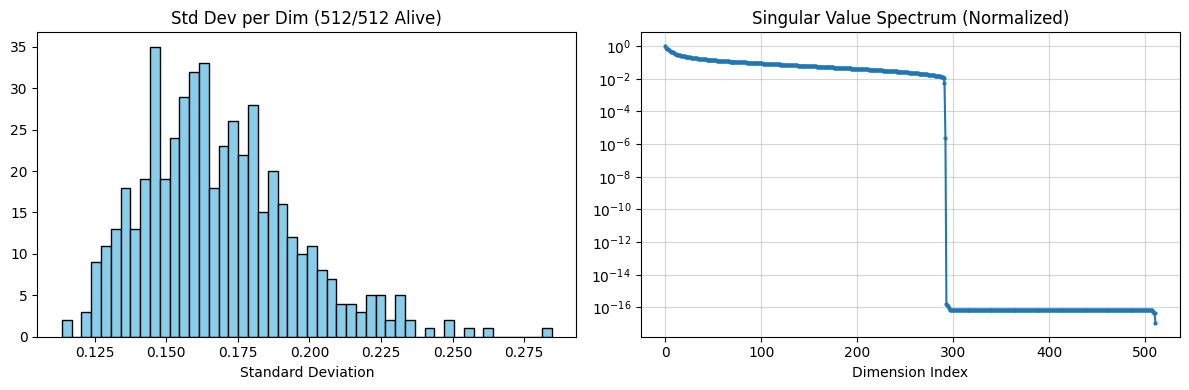

Total Alive Dimensions (Std > 0.1): 512
Effective Rank (99% Variance): 204


In [ ]:
import torch
import numpy as np

batch = next(iter(dataloader))

vlm_hidden = batch["image_latent"].to(device)
B, obs_h, num_layers, L, D = vlm_hidden.shape

ema_encoder.eval()

with torch.no_grad():
    vlm_hidden_flattened = vlm_hidden.view(B * obs_h, num_layers, L, D)
    enc_out = ema_encoder(vlm_hidden_flattened)

    latents = enc_out["latent"]

print(f"Analyzing Latents for Total Samples: {B * obs_h}")

probe_latent_health(latents)

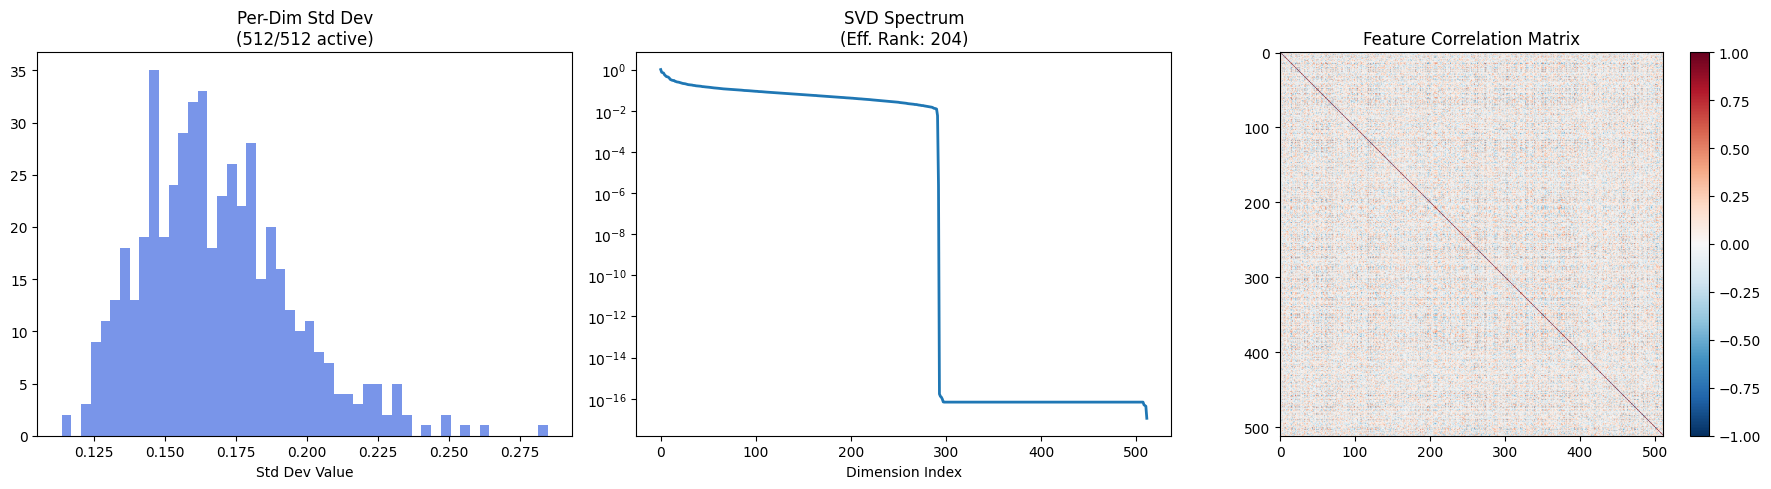

{'alive': np.int64(512), 'rank': np.int64(204)}

In [ ]:
analyze_latent_space(latents)

In [ ]:
planner = VisualTaskPlanner(
    num_pooling_queries = 32,
    latent_dim = 512,
    num_sampled_layers  = 4,
    q_hidden_dim = 768,
    num_attention_heads = 8,
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

In [ ]:
planner.load_encoder_weights(
    "/content/duplo_pusht_epoch_300.pt",
    key="ema_encoder",
)
planner.eval()

[load_encoder_weights] loaded 34 tensors from key='ema_encoder'


VisualTaskPlanner(
  (vlm): Qwen3VLForConditionalGeneration(
    (model): Qwen3VLModel(
      (visual): Qwen3VLVisionModel(
        (patch_embed): Qwen3VLVisionPatchEmbed(
          (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
        )
        (pos_embed): Embedding(2304, 1024)
        (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
        (blocks): ModuleList(
          (0-23): 24 x Qwen3VLVisionBlock(
            (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
            (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
            (attn): Qwen3VLVisionAttention(
              (qkv): Linear(in_features=1024, out_features=3072, bias=True)
              (proj): Linear(in_features=1024, out_features=1024, bias=True)
            )
            (mlp): Qwen3VLVisionMLP(
              (linear_fc1): Linear(in_features=1024, out_features=4096, bias=True)
              (linear_fc2): Linear(in_features=4096, out_features=1024, bias=True)


In [ ]:
policy.to("cuda").to(torch.bfloat16)
policy.eval()
planner.task_encoder.to("cuda")
planner.eval()                         # puts VLM + encoder in eval mode
policy_device = next(policy.parameters()).device

In [ ]:
import collections

import numpy as np
import torch
from IPython.display import Video, display
from PIL import Image
from skvideo.io import vwrite
from tqdm.auto import tqdm
import time

num_evals         = 50
max_steps         = 300
success_threshold = 0.8
vlm_stride        = 5
layer_indices     = [4, 12, 25, 34]
instruction       = "Push the T-shaped block to the target area."

ablate_latent = False

env = PushTImageEnv()

all_max_rewards = []
successes       = []
first_rollout_imgs = None

def get_latents_for_horizon(obs_deque):
    obs = obs_deque[-1]

    img = obs["image"]
    hwc = np.transpose(img, (1, 2, 0))

    if hwc.dtype == np.uint8:
        hwc_scaled = hwc.astype(np.float32)
    else:
        hwc_scaled = (hwc*255).astype(np.float32)

    all_h, _ = planner.extract_features_batch([hwc_scaled], [instruction])
    sampled_h = torch.stack([all_h[i] for i in layer_indices], dim=1)

    with torch.no_grad():
        enc_out = planner.task_encoder(vlm_hidden_states=sampled_h)
        # Returns (1, 32, 512)
        latent_seq = enc_out["latent_seq"]

    if ablate_latent:
        return torch.zeros_like(latent_seq)

    return latent_seq

def build_state(obs_deque):
    """
    Stack proprio across obs_horizon, normalize, flatten, cast to bf16.
    Matches state = nagent_pos.reshape(B, -1) in training.
    """
    agent_poses = np.stack([x["agent_pos"] for x in obs_deque])   # (obs_h, 2)
    nagent = normalize_data(agent_poses, stats=stats["agent_pos"])
    state = torch.from_numpy(nagent).to(
        device=policy_device, dtype=torch.bfloat16
    ).reshape(1, -1) # (1, obs_h * 2)
    return state

with torch.no_grad():
    for eval_idx in tqdm(range(num_evals), desc="Running Evals"):
        env.seed((eval_idx + 5) * 1000 + 42)
        obs, info = env.reset()
        obs_deque = collections.deque([obs] * obs_horizon, maxlen=obs_horizon)

        imgs = []
        if eval_idx == 0:
            imgs.append(env.render(mode="rgb_array"))

        step_idx = 0
        done = False
        rewards = []
        cached_latent = None
        steps_since_vlm = 0

        while step_idx < max_steps and not done:
            # Refresh the latent every vlm_stride env steps (matches training)
            if cached_latent is None or steps_since_vlm >= vlm_stride:
                cached_latent = get_latents_for_horizon(obs_deque)
                steps_since_vlm = 0

            state = build_state(obs_deque)
            cond_dict = {"latent": cached_latent}

            # Policy sampling (uses its own DPMSolver scheduler)
            action_pred = sample_fp32(policy, state, cond_dict, num_inference_steps=50)


            # policy.sample(
            #     state, cond_dict, num_inference_steps=50,
            # ) # bf16



            naction = action_pred.float().cpu().numpy()[0]

            action_pred_unnorm = unnormalize_data(naction, stats=stats["action"])

            action_chunk = action_pred_unnorm[
                obs_horizon - 1 : obs_horizon - 1 + action_horizon
            ]


            for a in action_chunk:
                if step_idx >= max_steps or done:
                    break
                obs, reward, terminated, truncated, info = env.step(a)

                rewards.append(reward)
                done = bool(terminated or truncated)
                obs_deque.append(obs)

                if eval_idx == 0:
                    imgs.append(env.render(mode="rgb_array"))

                step_idx += 1
                steps_since_vlm += 1

        rollout_max_reward = max(rewards) if rewards else 0.0
        is_success = rollout_max_reward > success_threshold

        all_max_rewards.append(rollout_max_reward)
        successes.append(is_success)

        print(
            f"Eval {eval_idx + 1:2d}/{num_evals} | "
            f"Steps: {step_idx:3d} | "
            f"Max Reward: {rollout_max_reward:.3f} | "
            f"Success: {is_success}"
        )

        if eval_idx == 0:
            first_rollout_imgs = imgs

success_rate = np.mean(successes) * 100
avg_reward = np.mean(all_max_rewards)

print("\n" + "=" * 40)
print(f"EVALUATION COMPLETE ({num_evals} Rollouts)")
print(f"Success Rate: {success_rate:.1f}%")
print(f"Average Max Reward: {avg_reward:.3f}")
print(f"Ablate latent: {ablate_latent}")
print("=" * 40 + "\n")

if first_rollout_imgs:
    vwrite("vis_eval_0.mp4", first_rollout_imgs)
    display(Video("vis_eval_0.mp4", embed=True, width=256, height=256))

In [ ]:
import numpy as np
import torch
from PIL import Image

env.seed(3 * 1000 + 42)
obs_a, _ = env.reset()
env.seed(7 * 1000 + 42)
obs_b, _ = env.reset()   # different random init -> different block pose

img_diff = np.abs(obs_a["image"] - obs_b["image"])
print(f"[1] Images differ: mean={img_diff.mean():.4f}, max={img_diff.max():.4f}")

def vlm_features(obs):
    img = (np.transpose(obs["image"], (1,2,0)) * 255).astype(np.uint8)
    all_h, _ = planner.extract_features_batch([Image.fromarray(img)], [instruction])
    return torch.stack([all_h[i] for i in layer_indices], dim=1)

feat_a = vlm_features(obs_a)
feat_b = vlm_features(obs_b)
feat_diff = (feat_a - feat_b).float().abs()
feat_rel = feat_diff.mean() / feat_a.float().abs().mean().clamp(min=1e-6)
print(f"[2] VLM features differ: mean_abs={feat_diff.mean():.4f}, relative={feat_rel:.4f}")

enc_a = planner.task_encoder(vlm_hidden_states=feat_a, key_padding_mask=None)
enc_b = planner.task_encoder(vlm_hidden_states=feat_b, key_padding_mask=None)

pooled_diff = (enc_a["pooled"] - enc_b["pooled"]).float().abs()
print(f"[3] Q-Pooler output differs: mean_abs={pooled_diff.mean():.4f}")

latent_diff = (enc_a["latent_seq_pre_gate"] - enc_b["latent_seq_pre_gate"]).float().abs()
print(f"[4] Final latent_seq_pre_gate differs: mean_abs={latent_diff.mean():.4f}")

print(f"\nLatent A[0,0,:5]: {enc_a['latent_seq_pre_gate'][0,0,:5].detach().float().cpu().numpy()}")
print(f"Latent B[0,0,:5]: {enc_b['latent_seq_pre_gate'][0,0,:5].detach().float().cpu().numpy()}")

[1] Images differ: mean=0.0171, max=0.7451
[2] VLM features differ: mean_abs=1.0994, relative=0.7712
[3] Q-Pooler output differs: mean_abs=0.2853
[4] Final latent_seq_pre_gate differs: mean_abs=0.1218

Latent A[0,0,:5]: [-1.796875   -0.46875    -0.30078125  1.2109375  -0.16503906]
Latent B[0,0,:5]: [-2.03125    -0.5390625  -0.37304688  0.6015625  -0.08935547]


In [ ]:
env.seed(1 * 1000 + 42)
obs_1, _ = env.reset()
env.seed(2 * 1000 + 42)
obs_2, _ = env.reset()
env.seed(3 * 1000 + 42)
obs_3, _ = env.reset()
print("agent_pos 1:", obs_1["agent_pos"])
print("agent_pos 2:", obs_2["agent_pos"])
print("agent_pos 3:", obs_3["agent_pos"])

# Check the full state if available
for i, o in enumerate([obs_1, obs_2, obs_3]):
    if "state" in o:
        print(f"state {i+1}:", o["state"])

agent_pos 1: [222. 353.]
agent_pos 2: [144. 417.]
agent_pos 3: [129. 340.]


In [ ]:
import zarr
raw = zarr.open("/content/pusht/pusht_cchi_v7_replay.zarr", mode="r")
print("First demo, first 10 (agent_pos, action):")
for i in range(10):
    print(f"  state={raw['data']['state'][i, :2]}  action={raw['data']['action'][i]}")

First demo, first 10 (agent_pos, action):
  state=[222.  97.]  action=[233.  71.]
  state=[225.2524   89.31253]  action=[229.  83.]
  state=[227.59233  84.53438]  action=[229.  86.]
  state=[228.42017  84.27986]  action=[230.  86.]
  state=[229.04222  84.9571 ]  action=[239.  89.]
  state=[232.16237  86.344  ]  action=[251.  95.]
  state=[238.84613  89.35484]  action=[263. 102.]
  state=[248.09006  94.06008]  action=[273. 108.]
  state=[258.14642  99.59151]  action=[283. 116.]
  state=[268.26694 105.99492]  action=[294. 127.]


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image


def probe_qpooler_attention(
    planner,
    env,
    instruction: str,
    layer_indices: list,
    num_scenes: int = 3,
    seeds: list | None = None,
):
    if seeds is None:
        seeds = [500 + i * 1000 for i in range(num_scenes)]

    results = []
    for seed in seeds:
        env.seed(seed)
        obs, _ = env.reset()
        img_hwc = (np.transpose(obs["image"], (1, 2, 0)) * 255).astype(np.uint8)

        pil_img = Image.fromarray(img_hwc).convert("RGB")
        all_h, mask = planner.extract_features_batch([pil_img], [instruction])
        sampled_h = torch.stack([all_h[i] for i in layer_indices], dim=1)

        enc_out = planner.task_encoder(
            vlm_hidden_states=sampled_h,
            key_padding_mask=None,
            return_attention_weights=True,
        )
        attn = enc_out["attention_weights"][0]

        inputs = planner.processor(
            text=[f"<|vision_start|><|image_pad|><|vision_end|>{instruction}"],
            images=[img_hwc],
            return_tensors="pt",
            padding=True,
        )
        input_ids = inputs["input_ids"][0].tolist()
        tokens = planner.processor.tokenizer.convert_ids_to_tokens(input_ids)

        L_text = sampled_h.shape[2]
        num_layers = sampled_h.shape[1]

        results.append({
            "attention": attn.detach().float().cpu(),
            "L_text": L_text,
            "num_layers": num_layers,
            "input_ids": input_ids,
            "tokens": tokens,
            "image": img_hwc,
            "seed": seed,
        })

    return results


def print_attention_summary(results, top_k: int = 5):
    for r in results:
        attn = r["attention"]
        L_text = r["L_text"]
        num_layers = r["num_layers"]
        tokens = r["tokens"]
        Q, L_total = attn.shape

        print(f"\n{'=' * 60}")
        print(f"Scene seed={r['seed']}")
        print(f"Queries: {Q}, memory size: {L_total} = {num_layers} layers x {L_text} tokens")

        layer_mass = attn.reshape(Q, num_layers, L_text).sum(dim=-1).mean(dim=0)
        print(f"\nPer-layer attention mass (averaged over queries):")
        for li, m in enumerate(layer_mass.tolist()):
            bar = "#" * int(m * 40)
            print(f"  layer slot {li}: {m:.3f}  {bar}")

        eps = 1e-9
        entropy = -(attn * (attn + eps).log()).sum(dim=-1)
        max_entropy = np.log(L_total)
        print(f"\nAttention entropy per query (max possible = {max_entropy:.3f}):")
        print(f"  min: {entropy.min():.3f}  mean: {entropy.mean():.3f}  max: {entropy.max():.3f}")
        print(f"  (low entropy = peaky / specific, high = uniform / ignoring memory)")

        print(f"\nTop-{top_k} attended tokens per query (first 5 queries):")
        for q in range(min(5, Q)):
            top_vals, top_idxs = attn[q].topk(top_k)
            pieces = []
            for v, idx in zip(top_vals.tolist(), top_idxs.tolist()):
                layer_id = idx // L_text
                token_id = idx % L_text
                tok = tokens[token_id] if token_id < len(tokens) else "?"
                pieces.append(f"L{layer_id}:t{token_id}({tok}):{v:.2f}")
            print(f"  Q{q}: " + "  ".join(pieces))


def plot_attention_heatmap(results, query_indices=None):
    if query_indices is None:
        query_indices = [0, 4, 8, 16, 24, 31]   # spread across the 32 queries

    n_scenes = len(results)
    first = results[0]
    num_layers = first["num_layers"]
    L_text = first["L_text"]

    for r in results:
        attn = r["attention"].reshape(
            -1, r["num_layers"], r["L_text"]
        ).numpy()

        n_q = len(query_indices)
        fig, axes = plt.subplots(
            n_q, num_layers,
            figsize=(num_layers * 3, n_q * 1.2),
            sharex=True, sharey=False,
        )
        if n_q == 1:
            axes = axes[None, :]

        for row, q in enumerate(query_indices):
            for col in range(num_layers):
                ax = axes[row][col]
                row_data = attn[q, col][None, :]   # (1, L_text)
                ax.imshow(row_data, aspect="auto", cmap="viridis",
                          vmin=0, vmax=attn[q].max())
                ax.set_yticks([])
                if row == 0:
                    ax.set_title(f"Layer slot {col}", fontsize=9)
                if col == 0:
                    ax.set_ylabel(f"Q{q}", rotation=0, labelpad=15, fontsize=9)

        fig.suptitle(f"Q-Pooler attention, seed={r['seed']}", y=1.02)
        plt.tight_layout()
        plt.show()


def compare_scene_attentions(results):
    print("\n" + "=" * 60)
    print("Cross-scene attention diff (Q-Pooler scene-specificity)")
    print("=" * 60)

    attns = [r["attention"] for r in results]
    for i in range(len(attns)):
        for j in range(i + 1, len(attns)):
            diff = (attns[i] - attns[j]).abs().mean().item()
            total_mass = attns[i].abs().mean().item()
            rel = diff / (total_mass + 1e-9)
            print(f"  scene{i} vs scene{j}: mean_abs_diff={diff:.4f}  "
                  f"relative={rel:.3f}")
    print("  (higher = attention is more scene-specific)")



Scene seed=500
Queries: 32, memory size: 304 = 4 layers x 76 tokens

Per-layer attention mass (averaged over queries):
  layer slot 0: 0.334  #############
  layer slot 1: 0.349  #############
  layer slot 2: 0.113  ####
  layer slot 3: 0.205  ########

Attention entropy per query (max possible = 5.717):
  min: 2.593  mean: 4.355  max: 5.082
  (low entropy = peaky / specific, high = uniform / ignoring memory)

Top-5 attended tokens per query (first 5 queries):
  Q0: L0:t21(<|image_pad|>):0.11  L0:t0(<|vision_start|>):0.05  L0:t72(Ġthe):0.05  L1:t66(Push):0.03  L0:t73(Ġtarget):0.03
  Q1: L0:t29(<|image_pad|>):0.11  L3:t0(<|vision_start|>):0.09  L0:t0(<|vision_start|>):0.06  L0:t72(Ġthe):0.05  L3:t25(<|image_pad|>):0.03
  Q2: L1:t55(<|image_pad|>):0.11  L3:t0(<|vision_start|>):0.06  L1:t42(<|image_pad|>):0.05  L1:t43(<|image_pad|>):0.03  L1:t20(<|image_pad|>):0.03
  Q3: L0:t29(<|image_pad|>):0.12  L0:t21(<|image_pad|>):0.12  L1:t34(<|image_pad|>):0.11  L1:t43(<|image_pad|>):0.10  L1:t47

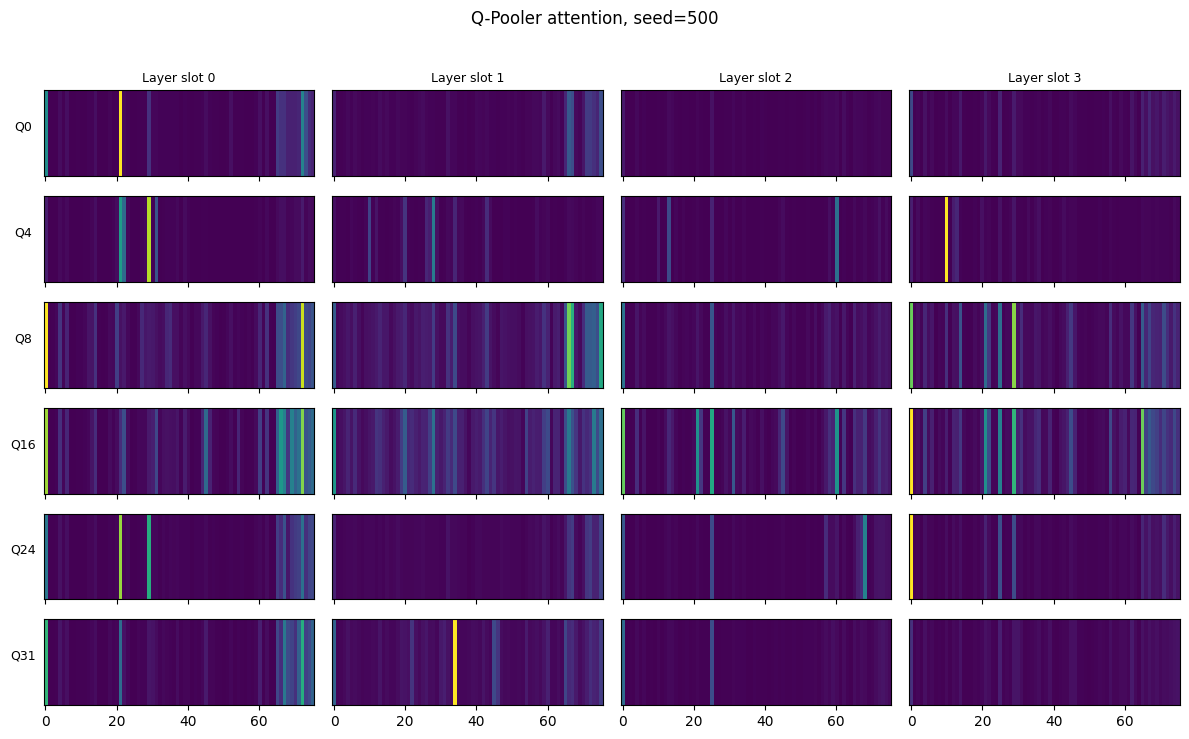

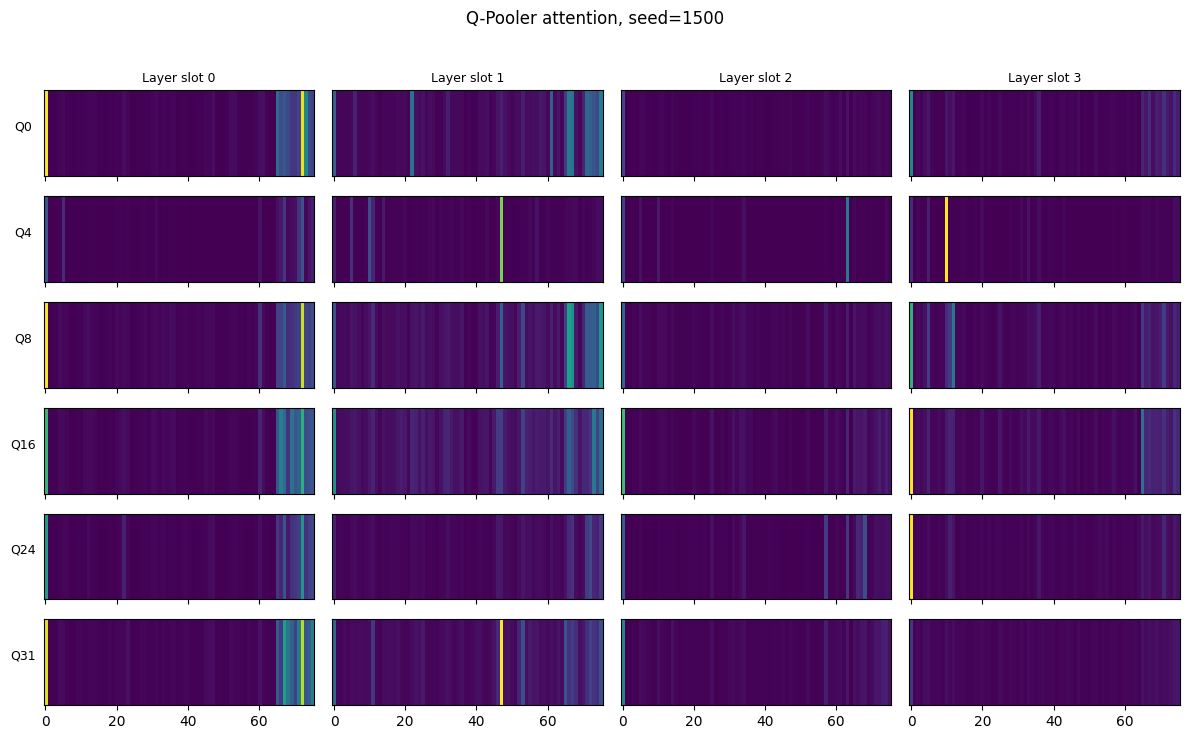

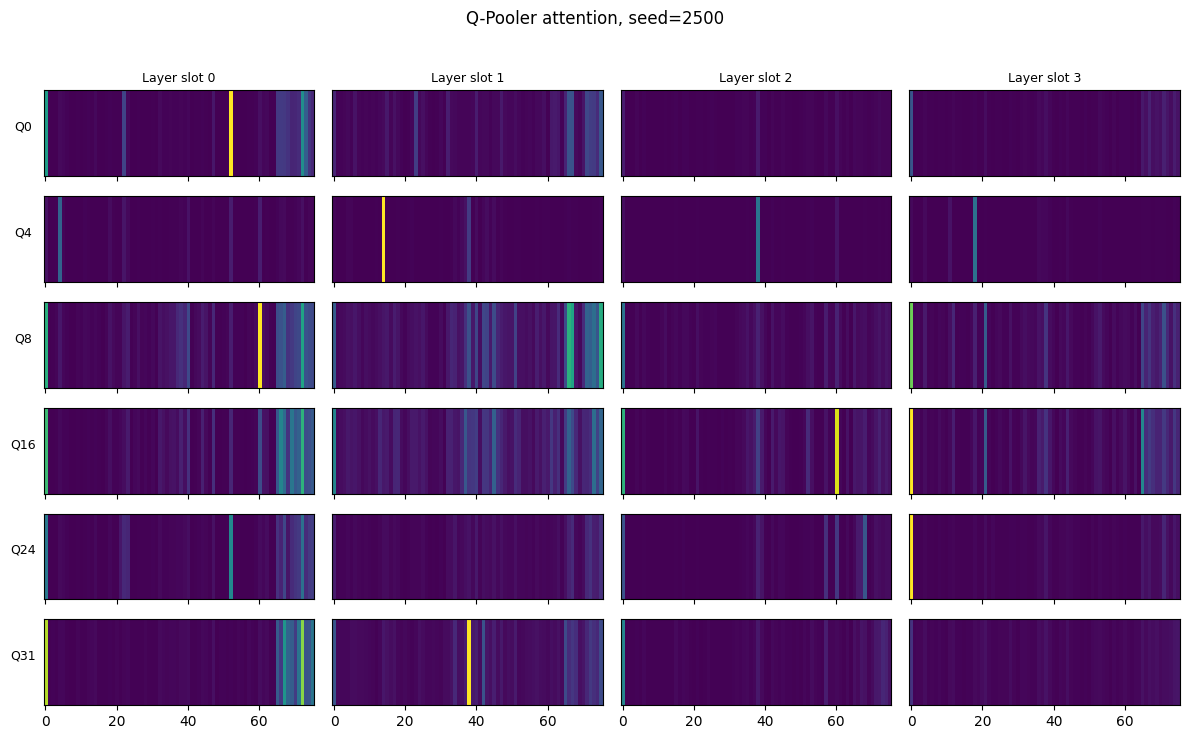

In [ ]:
results = probe_qpooler_attention(
    planner, env,
    instruction   = "Push the T-shaped block to the target area.",
    layer_indices = [4, 12, 25, 34],
    num_scenes    = 3,
)
print_attention_summary(results, top_k=5)
compare_scene_attentions(results)
plot_attention_heatmap(results, query_indices=[0, 4, 8, 16, 24, 31])

In [ ]:
for param in planner.task_encoder.parameters():
    param.requires_grad = False

for param in planner.vlm.parameters(): # If this is in memory
    param.requires_grad = False


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from tqdm.auto import tqdm

all_eps = sorted(set(int(e) for e in dataset.episode_id.tolist()))
rng = np.random.RandomState(0)
shuffled = list(all_eps)
rng.shuffle(shuffled)
n_train = int(0.8 * len(shuffled))
train_eps = set(shuffled[:n_train])
holdout_eps = set(shuffled[n_train:])
print(f"Train episodes: {len(train_eps)}  Holdout: {len(holdout_eps)}")

planner.task_encoder.eval()

train_z, train_y = [], []
holdout_z, holdout_y = [], []

with torch.no_grad():
    for batch in tqdm(dataloader, desc="Caching latents"):
        vlm_features = batch["image_latent"][:, -1].to(device, non_blocking=True)
        enc_out = planner.task_encoder(vlm_hidden_states=vlm_features)
        z = enc_out["latent_seq"].mean(dim=1)
        y = batch["agent_pos"][:, -1, :].to(device)
        ep_ids = batch["episode_id"].tolist()

        for i, ep in enumerate(ep_ids):
            if ep in train_eps:
                train_z.append(z[i].float().cpu())
                train_y.append(y[i].float().cpu())
            elif ep in holdout_eps:
                holdout_z.append(z[i].float().cpu())
                holdout_y.append(y[i].float().cpu())

train_z = torch.stack(train_z)
train_y = torch.stack(train_y)
holdout_z = torch.stack(holdout_z)
holdout_y = torch.stack(holdout_y)

print(f"Train: {train_z.shape[0]} samples  Holdout: {holdout_z.shape[0]} samples")

probe = nn.Linear(512, 2).to(device).float()
optimizer_p = torch.optim.Adam(probe.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()

# Mini-batch the cached data
batch_size = 256
num_train = train_z.shape[0]
num_epochs = 100

train_z_dev = train_z.to(device)
train_y_dev = train_y.to(device)
holdout_z_dev = holdout_z.to(device)
holdout_y_dev = holdout_y.to(device)

# Baseline: predicting the training mean
train_mean = train_y_dev.mean(dim=0, keepdim=True)
baseline_holdout = ((train_mean.expand_as(holdout_y_dev) - holdout_y_dev) ** 2).mean().item()
print(f"Baseline (predict-mean) holdout MSE: {baseline_holdout:.4f}")

print("\nTraining linear probe...")
for epoch in range(num_epochs):
    probe.train()
    perm = torch.randperm(num_train, device=device)
    epoch_loss = 0.0
    n_batches = 0

    for i in range(0, num_train, batch_size):
        idx = perm[i : i + batch_size]
        z_b = train_z_dev[idx]
        y_b = train_y_dev[idx]

        pred = probe(z_b)
        loss = criterion(pred, y_b)

        optimizer_p.zero_grad(set_to_none=True)
        loss.backward()
        optimizer_p.step()

        epoch_loss += loss.item()
        n_batches += 1

    # Held-out eval
    probe.eval()
    with torch.no_grad():
        holdout_pred = probe(holdout_z_dev)
        holdout_loss = criterion(holdout_pred, holdout_y_dev).item()

    train_loss = epoch_loss / n_batches
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:3d} | "
            f"train MSE: {train_loss:.5f} | "
            f"holdout MSE: {holdout_loss:.5f} | "
            f"baseline: {baseline_holdout:.4f}"
        )

print("\nFinal results:")
print(f"  Train MSE: {train_loss:.5f}")
print(f"  Holdout MSE: {holdout_loss:.5f}")
print(f"  Baseline: {baseline_holdout:.4f}  (predict-mean)")
print(f"  R^2: {1 - holdout_loss / baseline_holdout:.4f}")

Train episodes: 164  Holdout: 42


Caching latents:   0%|          | 0/94 [00:00<?, ?it/s]

Train: 19078 samples  Holdout: 4986 samples
Baseline (predict-mean) holdout MSE: 0.1806

Training linear probe...
Epoch   1 | train MSE: 0.08322 | holdout MSE: 0.03806 | baseline: 0.1806
Epoch  10 | train MSE: 0.01750 | holdout MSE: 0.01890 | baseline: 0.1806
Epoch  20 | train MSE: 0.01534 | holdout MSE: 0.01779 | baseline: 0.1806
Epoch  30 | train MSE: 0.01476 | holdout MSE: 0.01716 | baseline: 0.1806
Epoch  40 | train MSE: 0.01412 | holdout MSE: 0.01677 | baseline: 0.1806
Epoch  50 | train MSE: 0.01408 | holdout MSE: 0.01696 | baseline: 0.1806
Epoch  60 | train MSE: 0.01383 | holdout MSE: 0.01710 | baseline: 0.1806
Epoch  70 | train MSE: 0.01387 | holdout MSE: 0.01666 | baseline: 0.1806
Epoch  80 | train MSE: 0.01351 | holdout MSE: 0.01684 | baseline: 0.1806
Epoch  90 | train MSE: 0.01372 | holdout MSE: 0.01700 | baseline: 0.1806
Epoch 100 | train MSE: 0.01369 | holdout MSE: 0.01763 | baseline: 0.1806

Final results:
  Train MSE:    0.01369
  Holdout MSE:  0.01763
  Baseline:     0.1

In [ ]:
with torch.no_grad():
    obs, _ = env.reset()
    img_hwc = (np.transpose(obs["image"], (1, 2, 0)) * 255).astype(np.uint8)

    pil_img = Image.fromarray(img_hwc).convert("RGB")
    all_h, mask = planner.extract_features_batch([pil_img], [instruction])
    sampled_h = torch.stack([all_h[i] for i in layer_indices], dim=1)
    enc_out = planner.task_encoder(sampled_h)
    pre_gate = enc_out["latent_seq_pre_gate"]   # (B, Q, D)
    flat = pre_gate.reshape(-1, pre_gate.shape[-1]).float()
    std_per_dim = flat.std(dim=0)
    print(f"Pre-gate std per dim: mean={std_per_dim.mean():.4f}, "
          f"min={std_per_dim.min():.4f}, max={std_per_dim.max():.4f}")

Pre-gate std per dim: mean=0.2551, min=0.1360, max=0.6988


In [ ]:
print(f"prediction_type at construction: {policy.prediction_type}")
print(f"train scheduler config: {policy.train_scheduler.config.prediction_type}")
print(f"sample scheduler config: {policy.sample_scheduler.config.prediction_type}")

prediction_type at construction: epsilon
train scheduler config: epsilon
sample scheduler config: epsilon


In [ ]:
policy.eval()
with torch.no_grad():
    obs, _ = env.reset()
    obs_deque = collections.deque([obs] * obs_horizon, maxlen=obs_horizon)
    cached_latent = get_latents_for_horizon(obs_deque)
    state = build_state(obs_deque)
    cond_dict = {"latent": cached_latent}

    # Pure noise input at high t
    x = torch.randn(1, policy.horizon, policy.action_dim,
                    device=device, dtype=torch.bfloat16)

    for t_val in [999, 500, 100, 10]:
        t = torch.tensor([t_val], device=device)
        raw_pred = policy.forward_model(x, t, state, cond_dict)
        rp = raw_pred.float()
        print(f"t={t_val}: model output mean={rp.mean():.3f}, "
              f"std={rp.std():.3f}, "
              f"min={rp.min():.3f}, max={rp.max():.3f}")

t=999: model output mean=-0.002, std=0.869, min=-2.250, max=1.859
t=500: model output mean=-0.315, std=1.244, min=-3.312, max=2.375
t=100: model output mean=-0.955, std=3.303, min=-6.031, max=5.312
t=10: model output mean=-0.428, std=2.360, min=-4.875, max=3.672


In [ ]:
@torch.no_grad()
def sample_fp32(policy, state, cond_dict, num_inference_steps=100):
    B = state.shape[0]
    device = state.device

    policy.sample_scheduler.set_timesteps(num_inference_steps, device=device)
    x = torch.randn(B, policy.horizon, policy.action_dim,
                    device=device, dtype=torch.float32)

    policy_was_bf16 = next(policy.parameters()).dtype == torch.bfloat16
    if policy_was_bf16:
        policy.float()
    state_fp32 = state.float()
    cond_dict_fp32 = {k: v.float() for k, v in cond_dict.items()}

    # Cast scheduler buffers to fp32 if needed
    if hasattr(policy.sample_scheduler, 'alphas_cumprod'):
        if policy.sample_scheduler.alphas_cumprod.dtype != torch.float32:
            policy.sample_scheduler.alphas_cumprod = (
                policy.sample_scheduler.alphas_cumprod.float()
            )

    for t in policy.sample_scheduler.timesteps:
        t_batch = t.expand(B).to(device)
        model_out = policy.forward_model(x, t_batch, state_fp32, cond_dict_fp32)

        x = policy.sample_scheduler.step(model_out, t, x).prev_sample

    if policy_was_bf16:
        policy.to(torch.bfloat16)

    return x